In [1]:
import sys, os
sys.path.append("C:/Users/KimDongyoung/Desktop/Github/my_git/mygit/DEEPLEARNING/퍼셉트론")  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import pickle
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient
import mnist as mnist
import matplotlib.pyplot as plt

In [2]:
class SimpleConvNet:
    """단순한 합성곱 신경망
    
    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    """
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        
        acc = 0.0
        
        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt) 
        
        return acc / x.shape[0]

    def numerical_gradient(self, x, t):
        """기울기를 구한다（수치미분）.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        loss_w = lambda w: self.loss(x, t)

        grads = {}
        for idx in (1, 2, 3):
            grads['W' + str(idx)] = numerical_gradient(loss_w, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_w, self.params['b' + str(idx)])

        return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
        
    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]

In [5]:
from common.trainer import Trainer

In [6]:
# 데이터 읽기
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(flatten=False)

In [11]:
max_epochs = 10

network = SimpleConvNet(input_dim=(1,28,28), 
                        conv_param = {'filter_num': 10, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=50, output_size=10, weight_init_std=0.01)
                        
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=16,
                  optimizer='SGD', optimizer_param={'lr': 0.01}, # 고려해 볼 수 있는 포인트 3. optimizer 변경
                  evaluate_sample_num_per_epoch=10000) # 1에폭당 1000개의 데이터로 평가
trainer.train()



train loss:2.30207723280809
=== epoch:1, train acc:0.1008, test acc:0.0955 ===
train loss:2.3017766777081277
train loss:2.302577933502661
train loss:2.3024572876800296
train loss:2.3024090840307636
train loss:2.3022851296077116
train loss:2.301677357178708
train loss:2.3018255682663264
train loss:2.3020107074545377
train loss:2.3022441129741766
train loss:2.3023802959961257
train loss:2.3020133265770673
train loss:2.30232105972096
train loss:2.302755031534401
train loss:2.301603211372125
train loss:2.3016085624126372
train loss:2.3025546644581523
train loss:2.302627294581316
train loss:2.302448960223903
train loss:2.302981108615393
train loss:2.302179225044979
train loss:2.3026846287814378
train loss:2.3014110549267857
train loss:2.3019274771589417
train loss:2.302602456498139
train loss:2.301768268505442
train loss:2.302374748987848
train loss:2.302083466693398
train loss:2.302991495059818
train loss:2.301877452596764
train loss:2.3026534874107893
train loss:2.3018332615720283
train l

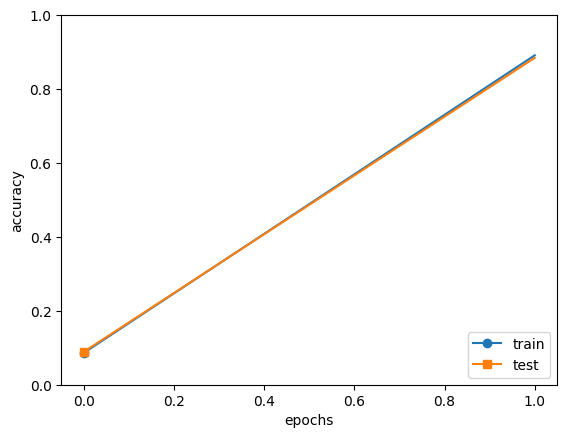

In [6]:
# # 매개변수 보존
# network.save_params("params.pkl")
# print("Saved Network Parameters!")

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### Convolution, Pooling 층을 하나 더 늘렸다. 

In [15]:
class ConvNet:
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1}, # filter_num: 필터 수, filter_size: 필터 크기, pad: 패딩, stride: 스트라이드
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2 * filter_pad) // filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size / 2) * (conv_output_size / 2))

        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(filter_num, filter_num, filter_size, filter_size)
        self.params['b2'] = np.zeros(filter_num)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b3'] = np.zeros(hidden_size)
        self.params['W4'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b4'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Conv2'] = Convolution(self.params['W2'], self.params['b2'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu2'] = Relu()
        self.layers['Pool2'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W3'], self.params['b3'])
        self.layers['Relu3'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W4'], self.params['b4'])

        self.last_layer = SoftmaxWithLoss()   # 출력층

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Conv2'].dW, self.layers['Conv2'].db
        grads['W3'], grads['b3'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W4'], grads['b4'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

In [18]:
# 데이터 읽기
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(flatten=False)

In [20]:
max_epochs = 2 

network = SimpleConvNet(input_dim=(1,28,28), 
                        conv_param = {'filter_num': 10, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=50, output_size=10, weight_init_std=0.01)
                        
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=16,
                  optimizer='SGD', optimizer_param={'lr': 0.01}, # 고려해 볼 수 있는 포인트 3. optimizer 변경
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

train loss:2.301768735863214
=== epoch:1, train acc:0.115, test acc:0.125 ===
train loss:2.301434872208837
train loss:2.3023362277382597
train loss:2.3020020564546657
train loss:2.302635702935197
train loss:2.301777888830582
train loss:2.302057188590069
train loss:2.3023726768877517
train loss:2.3028244411978984
train loss:2.3026815636208227
train loss:2.3017038835077517
train loss:2.3022424248949713
train loss:2.302327447827497
train loss:2.3025167797414428
train loss:2.301678171765047
train loss:2.302536713291569
train loss:2.3018622368318784
train loss:2.3016719328622335
train loss:2.301218058028245
train loss:2.302940699353775
train loss:2.301144457125731
train loss:2.300344730780859
train loss:2.3013347199754204
train loss:2.2987714530755787
train loss:2.3039607200627925
train loss:2.301171202532858
train loss:2.302113183671006
train loss:2.3024882489320664
train loss:2.299119266631311
train loss:2.3002439302152946
train loss:2.303765107730723
train loss:2.301664514641411
train lo